In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# @title Please enter the path to your CSV file in Google Drive
csv_file_path = "/content/drive/MyDrive/Data/Assignment/UCI_Credit_Card.csv" # @param {type:"string"}

if csv_file_path:
    try:
        df = pd.read_csv(csv_file_path)
        print(f"Successfully loaded '{csv_file_path}'")
        print("First 5 rows of the DataFrame:")
        display(df.head())
    except FileNotFoundError:
        print(f"Error: The file '{csv_file_path}' was not found. Please ensure the path is correct.")
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")
else:
    print("Please provide a CSV file path in the input field above.")

Successfully loaded '/content/drive/MyDrive/Data/Assignment/UCI_Credit_Card.csv'
First 5 rows of the DataFrame:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

None

In [5]:
print("Checking for missing values...")
try:
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100

    missing_df = pd.DataFrame({
        'Missing Count': missing_values,
        'Missing Percentage': missing_percentage
    })

    # Filter to show only columns with missing values and sort by count
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

    if missing_df.empty:
        print("No missing values found in the DataFrame.")
    else:
        print("\nMissing values per column:")
        display(missing_df)
except NameError:
    print("Error: The DataFrame 'df' is not defined.")
    print("This usually happens if the data loading cell (e.g., cell 'OMmVX1qp1kvi' where the CSV is read into 'df')")
    print("has not been executed yet, or if the runtime was reset. Please run the data loading cell first.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Checking for missing values...
No missing values found in the DataFrame.


In [6]:
continuous_vars = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

descriptive_stats = {}

for col in continuous_vars:
    stats = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode()[0], # mode() can return multiple values, take the first
        'Std Dev': df[col].std(),
        'Variance': df[col].var(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Q1 (25%)': df[col].quantile(0.25),
        'Q3 (75%)': df[col].quantile(0.75),
        'Skewness': df[col].skew(),
        'Kurtosis': df[col].kurtosis()
    }
    descriptive_stats[col] = stats

# Create a DataFrame from the dictionary of statistics
stats_df = pd.DataFrame(descriptive_stats).T

# Round all numerical values to 2 decimal places
stats_df = stats_df.round(2)

print("Descriptive Statistics for Continuous Variables:")
display(stats_df)

Descriptive Statistics for Continuous Variables:


,Mean,Median,Mode,Std Dev,Variance,Min,Max,Q1 (25%),Q3 (75%),Skewness,Kurtosis
LIMIT_BAL,167484.32,140000.0,50000.0,129747.66,1.683446e+10,10000.0,1000000.0,50000.00,240000.00,0.99,0.54
AGE,35.49,34.0,29.0,9.22,8.497000e+01,21.0,79.0,28.00,41.00,0.73,0.04
BILL_AMT1,51223.33,22381.5,0.0,73635.86,5.422240e+09,-165580.0,964511.0,3558.75,67091.00,2.66,9.81
BILL_AMT2,49179.08,21200.0,0.0,71173.77,5.065705e+09,-69777.0,983931.0,2984.75,64006.25,2.71,10.30
BILL_AMT3,47013.15,20088.5,0.0,69349.39,4.809338e+09,-157264.0,1664089.0,2666.25,60164.75,3.09,19.78
BILL_AMT4,43262.95,19052.0,0.0,64332.86,4.138716e+09,-170000.0,891586.0,2326.75,54506.00,2.82,11.31
BILL_AMT5,40311.40,18104.5,0.0,60797.16,3.696294e+09,-81334.0,927171.0,1763.00,50190.50,2.88,12.31
BILL_AMT6,38871.76,17071.0,0.0,59554.11,3.546692e+09,-339603.0,961664.0,1256.00,49198.25,2.85,12.27
PAY_AMT1,5663.58,2100.0,0.0,16563.28,2.743423e+08,0.0,873552.0,1000.00,5006.00,14.67,415.25
PAY_AMT2,5921.16,2009.0,0.0,23040.87,5.308817e+08,0.0,1684259.0,833.00,5000.00,30.45,1641.63


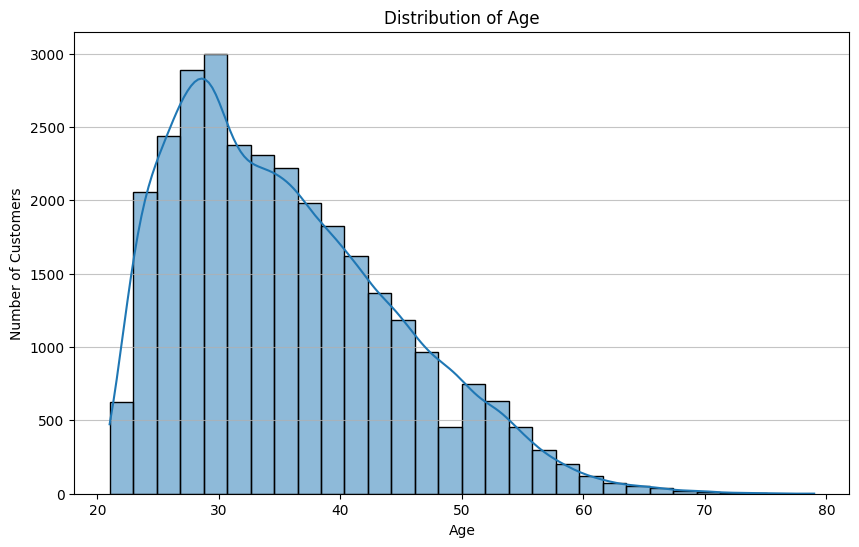

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histogram of AGE
plt.figure(figsize=(10, 6))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

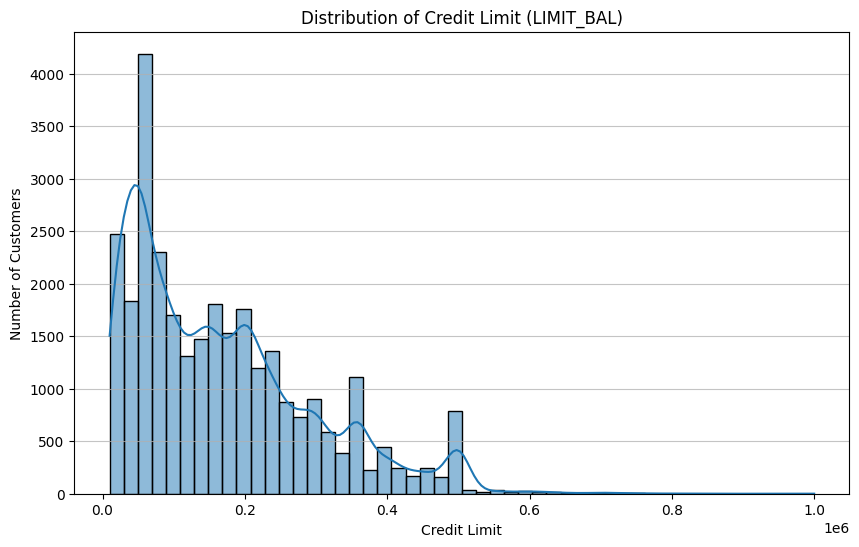

In [8]:
# 2. Histogram of LIMIT_BAL
plt.figure(figsize=(10, 6))
sns.histplot(df['LIMIT_BAL'], bins=50, kde=True)
plt.title('Distribution of Credit Limit (LIMIT_BAL)')
plt.xlabel('Credit Limit')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

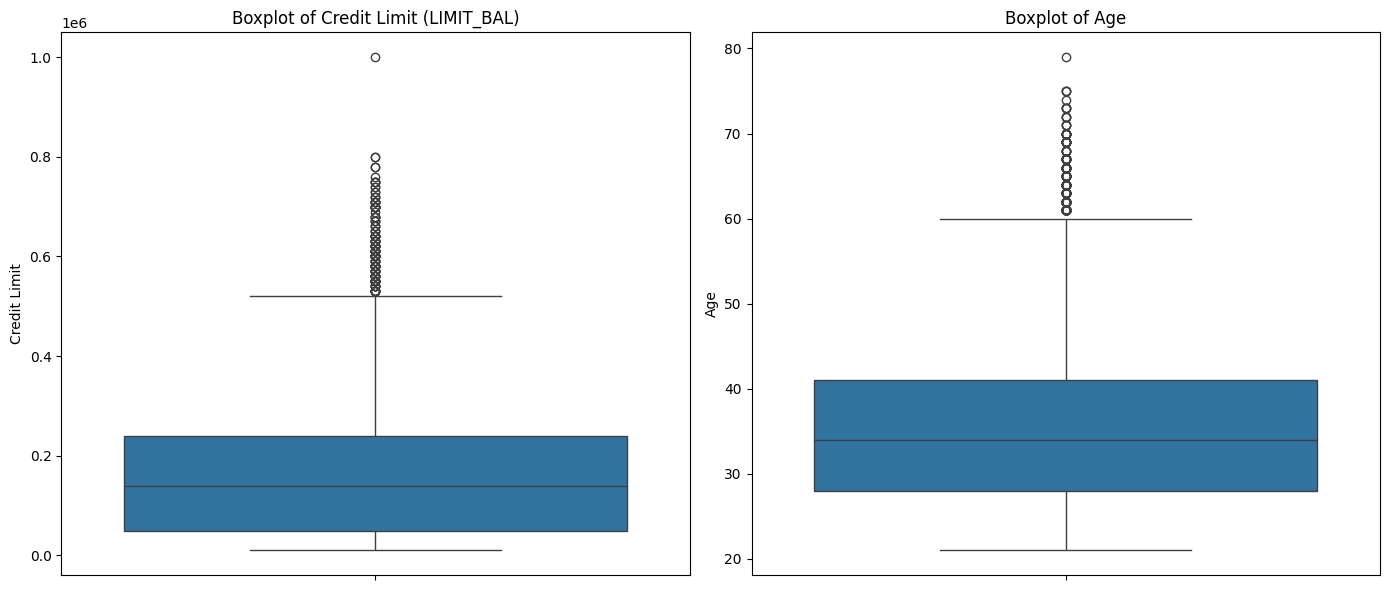

In [9]:
# 3. Boxplots for LIMIT_BAL and AGE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=df['LIMIT_BAL'])
plt.title('Boxplot of Credit Limit (LIMIT_BAL)')
plt.ylabel('Credit Limit')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['AGE'])
plt.title('Boxplot of Age')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

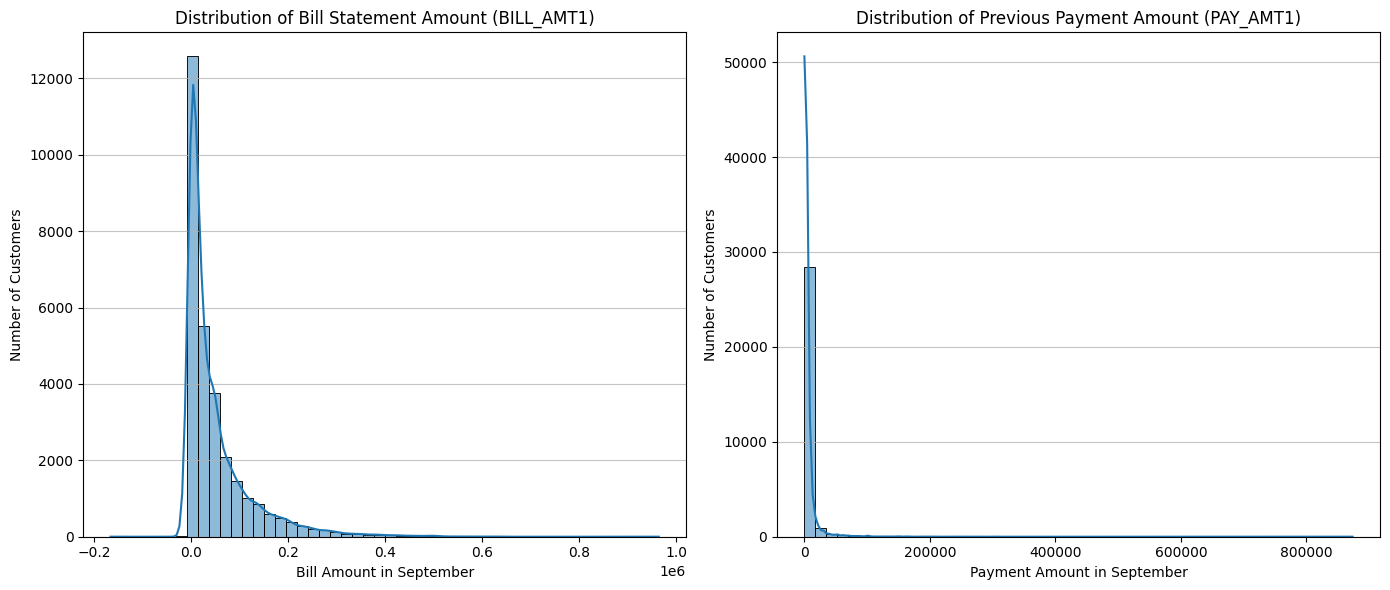

In [10]:
# 4. Histograms of BILL_AMT1 and PAY_AMT1
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['BILL_AMT1'], bins=50, kde=True)
plt.title('Distribution of Bill Statement Amount (BILL_AMT1)')
plt.xlabel('Bill Amount in September')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
sns.histplot(df['PAY_AMT1'], bins=50, kde=True)
plt.title('Distribution of Previous Payment Amount (PAY_AMT1)')
plt.xlabel('Payment Amount in September')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

/tmp/ipykernel_939/1136594570.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default.payment.next.month', data=df, palette='viridis')


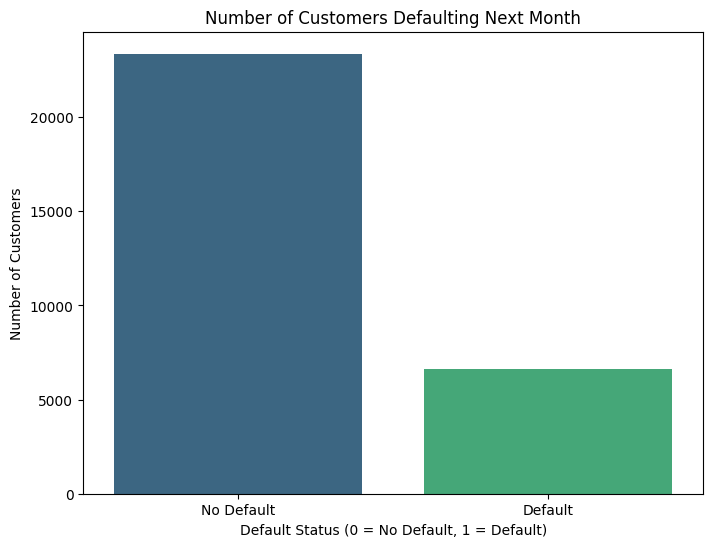

In [11]:
# 5. Bar chart showing the number of customers who defaulted versus did not default
plt.figure(figsize=(8, 6))
sns.countplot(x='default.payment.next.month', data=df, palette='viridis')
plt.title('Number of Customers Defaulting Next Month')
plt.xlabel('Default Status (0 = No Default, 1 = Default)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

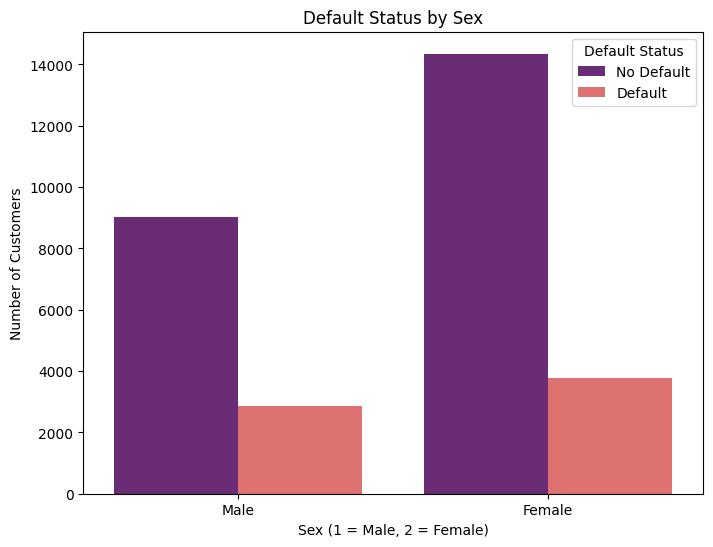

In [12]:
# 6. Bar chart showing default status by SEX
plt.figure(figsize=(8, 6))
sns.countplot(x='SEX', hue='default.payment.next.month', data=df, palette='magma')
plt.title('Default Status by Sex')
plt.xlabel('Sex (1 = Male, 2 = Female)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female']) # Assuming 1 and 2 in data, mapped to 0 and 1 here for plotting
plt.legend(title='Default Status', labels=['No Default', 'Default'])
plt.show()

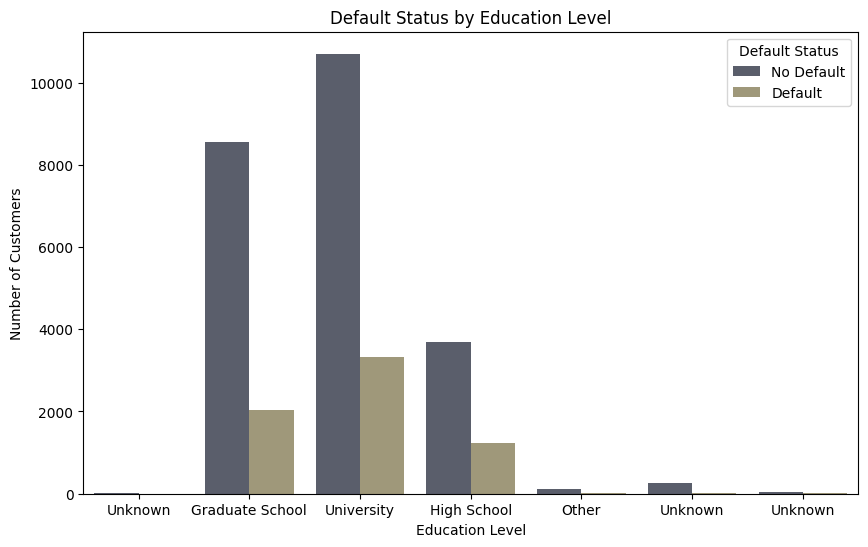

In [13]:
# 7. Bar chart showing default status by EDUCATION
plt.figure(figsize=(10, 6))
sns.countplot(x='EDUCATION', hue='default.payment.next.month', data=df, palette='cividis')
plt.title('Default Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.legend(title='Default Status', labels=['No Default', 'Default'])
# Map education levels for better readability (adjust if actual values differ)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6],
           labels=['Unknown', 'Graduate School', 'University', 'High School', 'Other', 'Unknown', 'Unknown'])
plt.show()

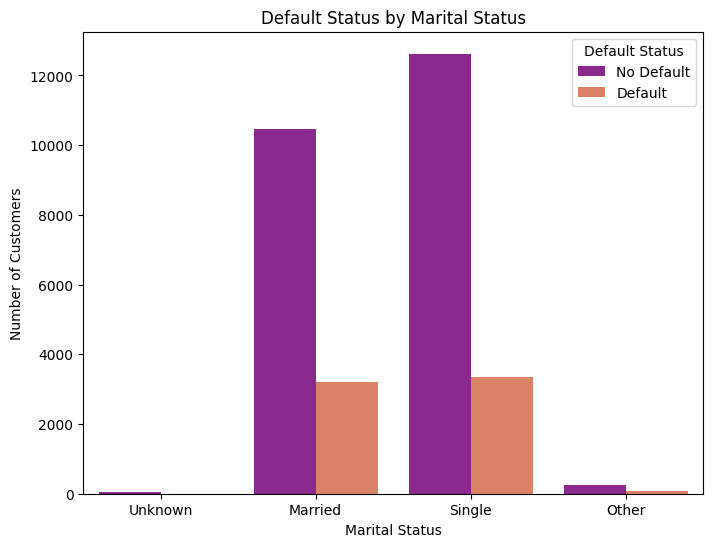

In [14]:
# 8. Bar chart showing default status by MARRIAGE
plt.figure(figsize=(8, 6))
sns.countplot(x='MARRIAGE', hue='default.payment.next.month', data=df, palette='plasma')
plt.title('Default Status by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.legend(title='Default Status', labels=['No Default', 'Default'])
# Map marriage levels for better readability (adjust if actual values differ)
plt.xticks(ticks=[0, 1, 2, 3],
           labels=['Unknown', 'Married', 'Single', 'Other'])
plt.show()

In [15]:
categorical_vars = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6',
    'default.payment.next.month'
]

for col in categorical_vars:
    print(f"\n--- Frequency Distribution for {col} ---")

    # Calculate frequency (count)
    frequency = df[col].value_counts().reset_index()
    frequency.columns = ['Category', 'Frequency']

    # Calculate percentage
    total_count = frequency['Frequency'].sum()
    frequency['Percentage'] = (frequency['Frequency'] / total_count * 100).round(2)

    # Sort by category for consistency (optional, can be removed if order doesn't matter)
    frequency = frequency.sort_values(by='Category').reset_index(drop=True)

    display(frequency)


--- Frequency Distribution for SEX ---


,Category,Frequency,Percentage
0,1,11888,39.63
1,2,18112,60.37



--- Frequency Distribution for EDUCATION ---


,Category,Frequency,Percentage
0,0,14,0.05
1,1,10585,35.28
2,2,14030,46.77
3,3,4917,16.39
4,4,123,0.41
5,5,280,0.93
6,6,51,0.17



--- Frequency Distribution for MARRIAGE ---


...

,Category,Frequency,Percentage
0,-2,4546,15.15
1,-1,5539,18.46
2,0,16947,56.49
3,2,2626,8.75
4,3,178,0.59
5,4,84,0.28
6,5,17,0.06
7,6,4,0.01
8,7,58,0.19
9,8,1,0.00



--- Frequency Distribution for PAY_6 ---


,Category,Frequency,Percentage
0,-2,4895,16.32
1,-1,5740,19.13
2,0,16286,54.29
3,2,2766,9.22
4,3,184,0.61
5,4,49,0.16
6,5,13,0.04
7,6,19,0.06
8,7,46,0.15
9,8,2,0.01



--- Frequency Distribution for default.payment.next.month ---


,Category,Frequency,Percentage
0,0,23364,77.88
1,1,6636,22.12


/tmp/ipykernel_939/1767569402.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default.payment.next.month', data=df, palette='viridis')


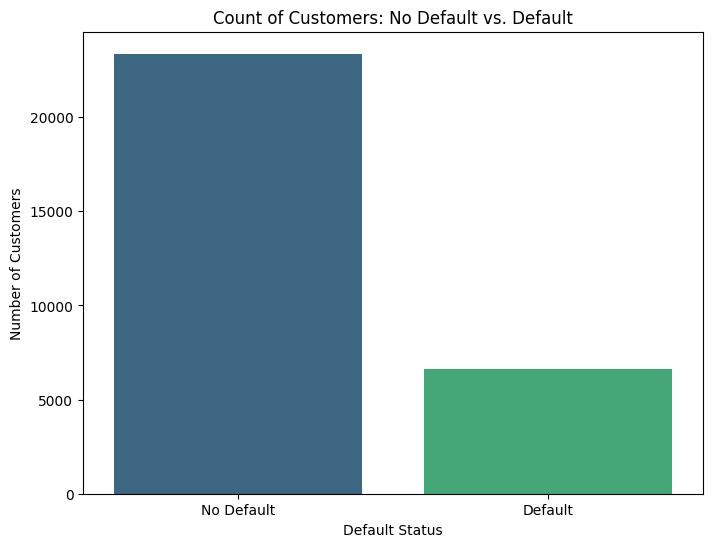

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Countplot showing No Default (0) vs Default (1)
plt.figure(figsize=(8, 6))
sns.countplot(x='default.payment.next.month', data=df, palette='viridis')
plt.title('Count of Customers: No Default vs. Default')
plt.xlabel('Default Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

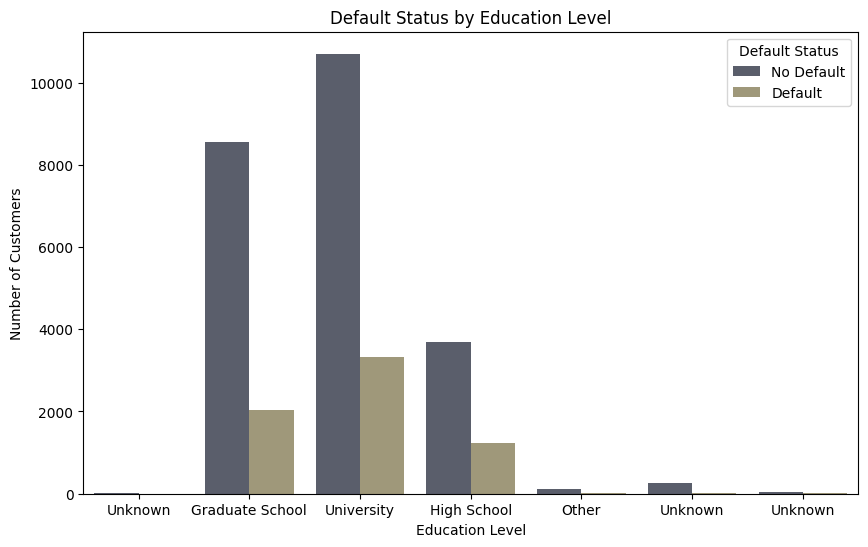

In [17]:
# 2. Countplot showing default status by EDUCATION
plt.figure(figsize=(10, 6))
sns.countplot(x='EDUCATION', hue='default.payment.next.month', data=df, palette='cividis')
plt.title('Default Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.legend(title='Default Status', labels=['No Default', 'Default'])
# Map education levels for better readability
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6],
           labels=['Unknown', 'Graduate School', 'University', 'High School', 'Other', 'Unknown', 'Unknown'])
plt.show()

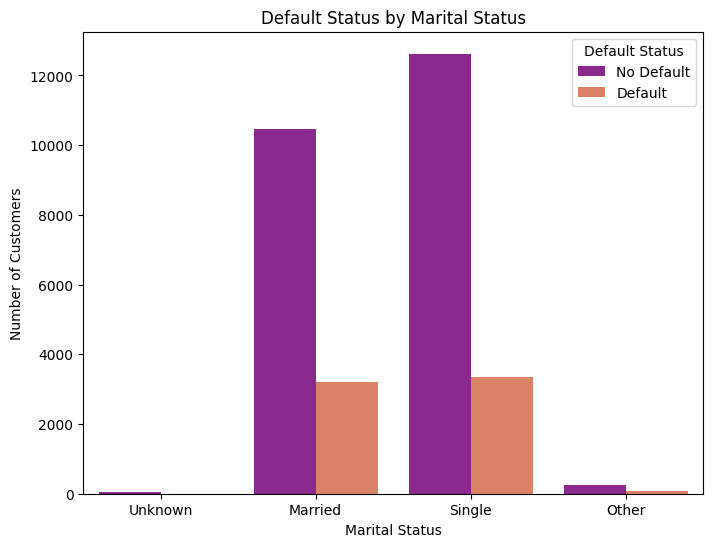

In [18]:
# 3. Countplot showing default status by MARRIAGE
plt.figure(figsize=(8, 6))
sns.countplot(x='MARRIAGE', hue='default.payment.next.month', data=df, palette='plasma')
plt.title('Default Status by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')
plt.legend(title='Default Status', labels=['No Default', 'Default'])
# Map marriage levels for better readability
plt.xticks(ticks=[0, 1, 2, 3],
           labels=['Unknown', 'Married', 'Single', 'Other'])
plt.show()

/tmp/ipykernel_939/1225695379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df, palette='coolwarm')


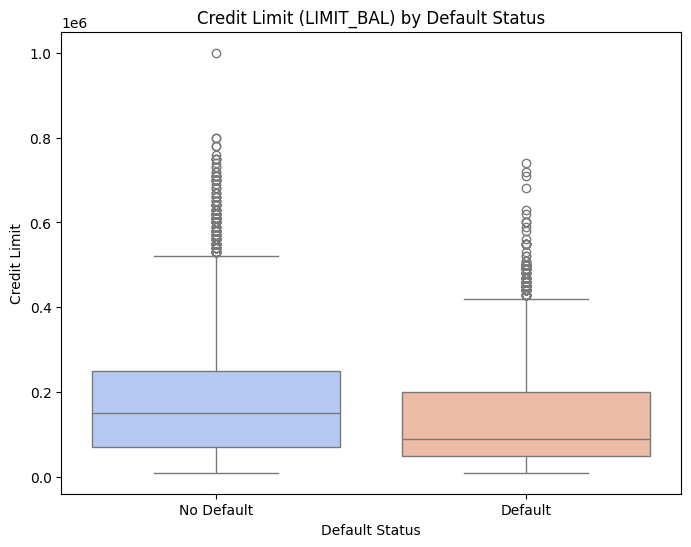

In [19]:
# 4. Boxplot comparing LIMIT_BAL for No Default and Default customers
plt.figure(figsize=(8, 6))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df, palette='coolwarm')
plt.title('Credit Limit (LIMIT_BAL) by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Credit Limit')
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

/tmp/ipykernel_939/3624448081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default.payment.next.month', y='AGE', data=df, palette='coolwarm')


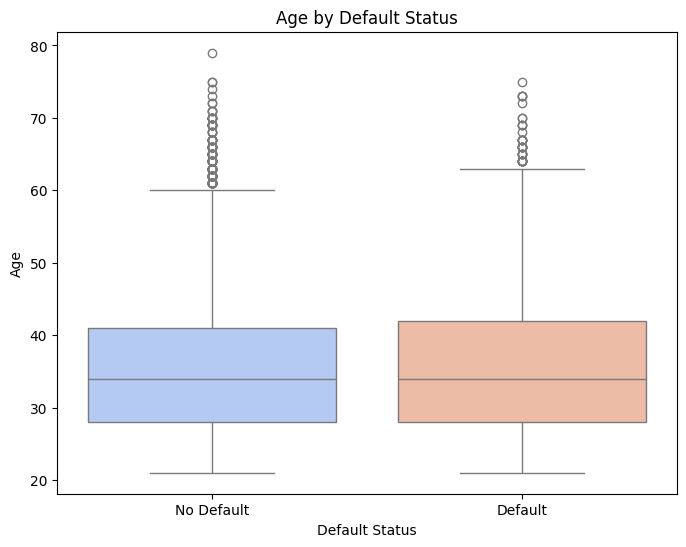

In [20]:
# 5. Boxplot comparing AGE for No Default and Default customers
plt.figure(figsize=(8, 6))
sns.boxplot(x='default.payment.next.month', y='AGE', data=df, palette='coolwarm')
plt.title('Age by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

/tmp/ipykernel_939/1197690063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default.payment.next.month', y='PAY_AMT1', data=df, palette='coolwarm')


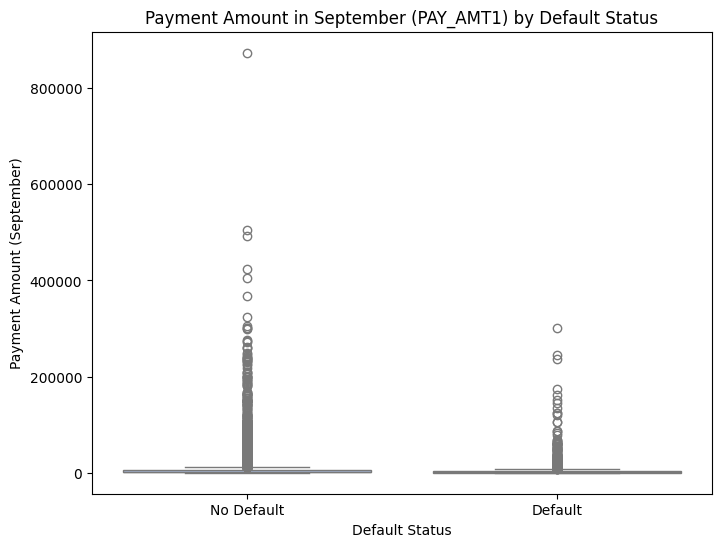

In [21]:
# 6. Boxplot comparing PAY_AMT1 for No Default and Default customers
plt.figure(figsize=(8, 6))
sns.boxplot(x='default.payment.next.month', y='PAY_AMT1', data=df, palette='coolwarm')
plt.title('Payment Amount in September (PAY_AMT1) by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Payment Amount (September)')
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

/tmp/ipykernel_939/1244539587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default.payment.next.month', y='BILL_AMT1', data=df, palette='coolwarm')


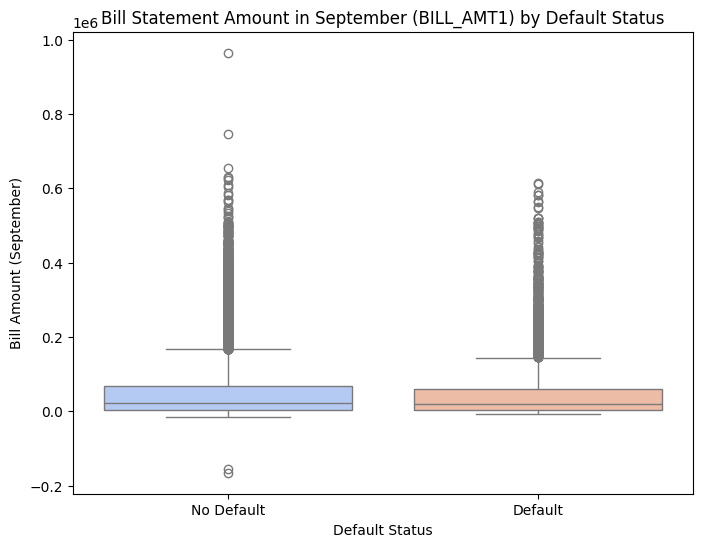

In [22]:
# 7. Boxplot comparing BILL_AMT1 for No Default and Default customers
plt.figure(figsize=(8, 6))
sns.boxplot(x='default.payment.next.month', y='BILL_AMT1', data=df, palette='coolwarm')
plt.title('Bill Statement Amount in September (BILL_AMT1) by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Bill Amount (September)')
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

### Outlier Detection using IQR Method

In [23]:
outlier_results = []

continuous_vars_for_outliers = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

for col in continuous_vars_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)
    percentage_outliers = (num_outliers / len(df)) * 100

    outlier_results.append({
        'Variable': col,
        'Q1 (25th percentile)': round(Q1, 2),
        'Q3 (75th percentile)': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Number of Outliers': num_outliers,
        'Percentage of Outliers': round(percentage_outliers, 2)
    })

# Create a DataFrame for the summary table
outlier_summary_df = pd.DataFrame(outlier_results)

print("Summary of Outlier Detection (IQR Method):")
display(outlier_summary_df)

Summary of Outlier Detection (IQR Method):


,Variable,Q1 (25th percentile),Q3 (75th percentile),IQR,Lower Bound,Upper Bound,Number of Outliers,Percentage of Outliers
0,LIMIT_BAL,50000.00,240000.00,190000.00,-235000.00,525000.00,167,0.56
1,AGE,28.00,41.00,13.00,8.50,60.50,272,0.91
2,BILL_AMT1,3558.75,67091.00,63532.25,-91739.62,162389.38,2400,8.00
3,BILL_AMT2,2984.75,64006.25,61021.50,-88547.50,155538.50,2395,7.98
4,BILL_AMT3,2666.25,60164.75,57498.50,-83581.50,146412.50,2469,8.23
5,BILL_AMT4,2326.75,54506.00,52179.25,-75942.12,132774.88,2622,8.74
6,BILL_AMT5,1763.00,50190.50,48427.50,-70878.25,122831.75,2725,9.08
7,BILL_AMT6,1256.00,49198.25,47942.25,-70657.38,121111.62,2693,8.98
8,PAY_AMT1,1000.00,5006.00,4006.00,-5009.00,11015.00,2745,9.15
9,PAY_AMT2,833.00,5000.00,4167.00,-5417.50,11250.50,2714,9.05


### Visualizing Outliers with Boxplots

### Correlation Analysis

In [24]:
numerical_vars_for_correlation = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6',
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6',
    'default.payment.next.month'
]

# Calculate the Pearson correlation matrix
correlation_matrix = df[numerical_vars_for_correlation].corr(method='pearson')

# Display the correlation matrix
print("Pearson Correlation Matrix:")
display(correlation_matrix)

Pearson Correlation Matrix:


,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
LIMIT_BAL,1.000000,0.144713,0.285430,0.278314,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
AGE,0.144713,1.000000,0.056239,0.054283,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
BILL_AMT1,0.285430,0.056239,1.000000,0.951484,0.892279,0.860272,0.829779,0.802650,0.140277,0.099355,0.156887,0.158303,0.167026,0.179341,-0.019644
BILL_AMT2,0.278314,0.054283,0.951484,1.000000,0.928326,0.892482,0.859778,0.831594,0.280365,0.100851,0.150718,0.147398,0.157957,0.174256,-0.014193
BILL_AMT3,0.283236,0.053710,0.892279,0.928326,1.000000,0.923969,0.883910,0.853320,0.244335,0.316936,0.130011,0.143405,0.179712,0.182326,-0.014076
BILL_AMT4,0.293988,0.051353,0.860272,0.892482,0.923969,1.000000,0.940134,0.900941,0.233012,0.207564,0.300023,0.130191,0.160433,0.177637,-0.010156
BILL_AMT5,0.295562,0.049345,0.829779,0.859778,0.883910,0.940134,1.000000,0.946197,0.217031,0.181246,0.252305,0.293118,0.141574,0.164184,-0.006760
BILL_AMT6,0.290389,0.047613,0.802650,0.831594,0.853320,0.900941,0.946197,1.000000,0.199965,0.172663,0.233770,0.250237,0.307729,0.115494,-0.005372
PAY_AMT1,0.195236,0.026147,0.140277,0.280365,0.244335,0.233012,0.217031,0.199965,1.000000,0.285576,0.252191,0.199558,0.148459,0.185735,-0.072929
PAY_AMT2,0.178408,0.021785,0.099355,0.100851,0.316936,0.207564,0.181246,0.172663,0.285576,1.000000,0.244770,0.180107,0.180908,0.157634,-0.058579


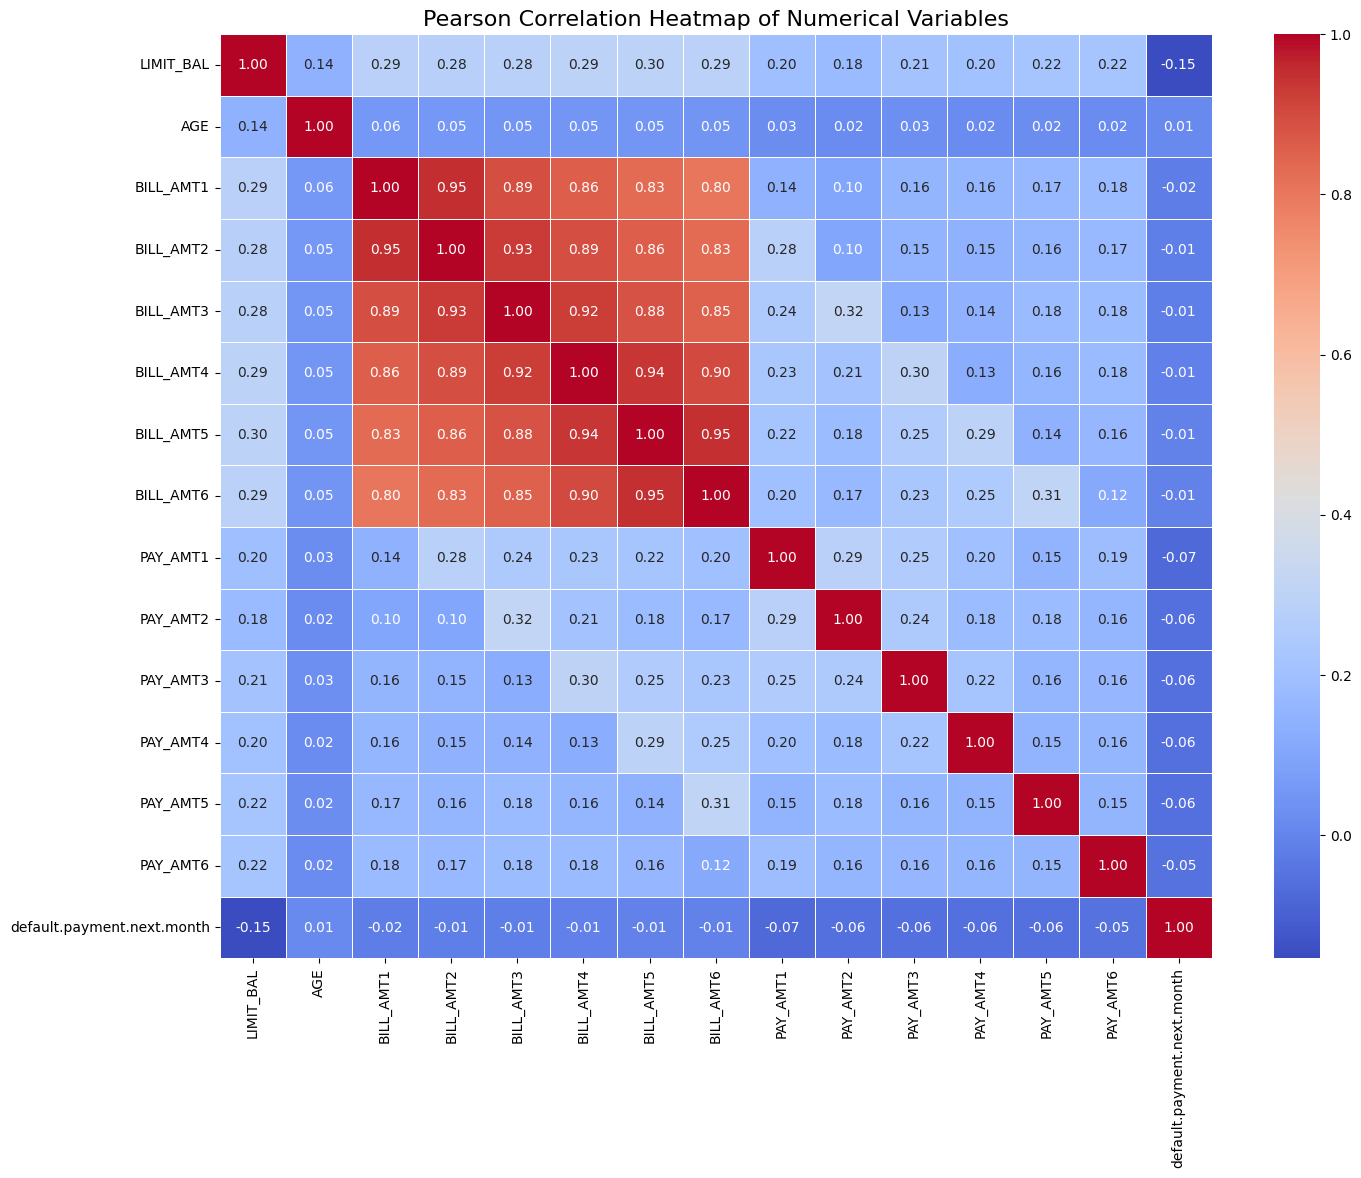

In [25]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Heatmap of Numerical Variables', fontsize=16)
plt.show()

In [26]:
# Extract correlations with the target variable
default_correlation = correlation_matrix['default.payment.next.month'].sort_values(ascending=False)

print("Correlation with 'default.payment.next.month':\n")
display(default_correlation)

# Identify variables with strongest positive and negative correlations
strongest_positive = default_correlation[default_correlation.index != 'default.payment.next.month'].idxmax()
strongest_positive_value = default_correlation[strongest_positive]

strongest_negative = default_correlation[default_correlation.index != 'default.payment.next.month'].idxmin()
strongest_negative_value = default_correlation[strongest_negative]

print(f"\nVariable with strongest positive correlation with default: '{strongest_positive}' (Correlation: {strongest_positive_value:.2f})")
print(f"Variable with strongest negative correlation with default: '{strongest_negative}' (Correlation: {strongest_negative_value:.2f})")

print("\nExplanation:\n")
print(f"The correlation analysis reveals that '{strongest_positive}' has the strongest positive linear relationship with the likelihood of default. This means that as '{strongest_positive}' tends to increase, the probability of default also tends to increase. Conversely, '{strongest_negative}' shows the strongest negative linear relationship, suggesting that as '{strongest_negative}' increases, the probability of default tends to decrease.")
print("\nIt's important to remember that correlation does not imply causation. These relationships indicate tendencies within the data, which can be valuable for understanding potential risk factors but do not establish direct cause-and-effect.")

Correlation with 'default.payment.next.month':



,default.payment.next.month
default.payment.next.month,1.000000
AGE,0.013890
BILL_AMT6,-0.005372
BILL_AMT5,-0.006760
BILL_AMT4,-0.010156
BILL_AMT3,-0.014076
BILL_AMT2,-0.014193
BILL_AMT1,-0.019644
PAY_AMT6,-0.053183
PAY_AMT5,-0.055124



Variable with strongest positive correlation with default: 'AGE' (Correlation: 0.01)
Variable with strongest negative correlation with default: 'LIMIT_BAL' (Correlation: -0.15)

Explanation:

The correlation analysis reveals that 'AGE' has the strongest positive linear relationship with the likelihood of default. This means that as 'AGE' tends to increase, the probability of default also tends to increase. Conversely, 'LIMIT_BAL' shows the strongest negative linear relationship, suggesting that as 'LIMIT_BAL' increases, the probability of default tends to decrease.

It's important to remember that correlation does not imply causation. These relationships indicate tendencies within the data, which can be valuable for understanding potential risk factors but do not establish direct cause-and-effect.


## Machine Learning Model: Logistic Regression for Credit Card Default Prediction

### STEP 1 — Prepare X and y

In [27]:
import pandas as pd

# Define the target variable (y)
y = df['default.payment.next.month']

# Define the feature set (X) by dropping 'ID' and the target variable
X = df.drop(['ID', 'default.payment.next.month'], axis=1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 values of y:")
display(y.head())

Shape of X: (30000, 23)
Shape of y: (30000,)

First 5 rows of X:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,120000.0,2,2,2,26,-1,2,0,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,90000.0,2,2,2,34,0,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,50000.0,2,2,1,37,0,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0



First 5 values of y:


,default.payment.next.month
0,1
1,1
2,0
3,0
4,0


### STEP 2 — Train-test split

In [28]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (24000, 23)
X_test shape: (6000, 23)
y_train shape: (24000,)
y_test shape: (6000,)


### STEP 3 — Preprocessing

In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns from X
# Based on df.info() and common knowledge for this dataset
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
continuous_cols = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore') # handle_unknown='ignore' to prevent errors for unseen categories

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, continuous_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Preprocessing setup complete using StandardScaler for numerical features and OneHotEncoder for categorical features.")

Preprocessing setup complete using StandardScaler for numerical features and OneHotEncoder for categorical features.


### STEP 4 — Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

# Create the full pipeline with preprocessing and Logistic Regression model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))
])

# Train the model
print("Training Logistic Regression model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.")

Training Logistic Regression model...
Model training complete.


### STEP 5 — Prediction

In [31]:
# Predict the default class for the test dataset
y_pred = model_pipeline.predict(X_test)

print("Predictions on the test set have been made.")
print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test[:10].values)

Predictions on the test set have been made.
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 actual values: [0 0 0 1 0 0 0 0 0 0]


### STEP 6 — Model evaluation

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix (Raw):")
cm = confusion_matrix(y_test, y_pred)
display(cm)

Accuracy: 0.8170
Precision: 0.6629
Recall: 0.3512
F1-Score: 0.4591

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000


Confusion Matrix (Raw):


array([[4436,  237],
       [ 861,  466]])

### STEP 7 — Confusion matrix visualization

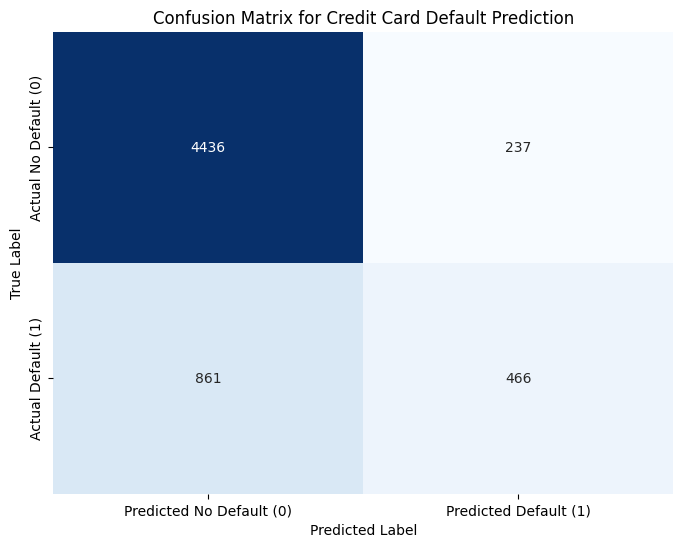

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for the confusion matrix for better visualization
cm_df = pd.DataFrame(cm, index=['Actual No Default (0)', 'Actual Default (1)'], columns=['Predicted No Default (0)', 'Predicted Default (1)'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Credit Card Default Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()